
# Assignment: Phân loại Email/SMS Spam bằng Logistic Regression

## Mục tiêu bài tập

Trong notebook này, ta sẽ xây dựng một mô hình Machine Learning để phân loại tin nhắn/email thành:

- **Ham**: không phải spam
- **Spam**: tin nhắn rác / quảng cáo / lừa đảo

Bài này dùng **Logistic Regression** vì đây là thuật toán cơ bản nhưng rất mạnh cho bài toán **binary classification**.

---

## Dataset sử dụng

Ta ưu tiên dùng **dataset thật từ Kaggle**, không dùng dữ liệu random.

Dataset được dùng:

**SMS Spam Collection Dataset**

Dataset này gồm khoảng hơn 5,000 tin nhắn đã được gán nhãn:

| Label | Ý nghĩa |
|---|---|
| ham | Không spam |
| spam | Spam |

---

## Pipeline tổng quát

```text
Raw text
   ↓
Load dataset
   ↓
Clean data
   ↓
Encode label
   ↓
TF-IDF vectorization
   ↓
Train/Test split
   ↓
Train Logistic Regression
   ↓
Evaluate model
   ↓
Predict new messages
```



# 1. Cài đặt thư viện cần thiết

Nếu chạy trên máy cá nhân hoặc Google Colab, có thể cần cài thêm `kagglehub`.

`kagglehub` giúp tải dataset trực tiếp từ Kaggle.


In [ ]:

# Nếu chưa có kagglehub thì chạy dòng này
# !pip install kagglehub



# 2. Import thư viện

Ta cần các nhóm thư viện chính:

- `pandas`: đọc và xử lý dữ liệu dạng bảng
- `sklearn`: chia dữ liệu, vector hóa text, train model và đánh giá model
- `matplotlib`: vẽ biểu đồ


In [1]:

import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)



# 3. Tải dataset thật từ Kaggle

Dataset được tải bằng `kagglehub`.

Lưu ý:

Nếu máy yêu cầu đăng nhập Kaggle, bạn cần cấu hình Kaggle API token.  
Nếu chạy trên Google Colab, cách đơn giản nhất là upload file `kaggle.json`.



# 4. Đọc dữ liệu

Dataset thường có file `spam.csv`.

File này có encoding là `latin-1`, vì vậy khi đọc bằng pandas ta dùng:

```python
encoding="latin-1"
```

Một số cột phụ không cần thiết sẽ được xóa đi.


In [2]:

df = pd.read_csv("../data/email_spam/spam.csv", encoding="latin-1")

df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN



# 5. Kiểm tra cấu trúc dữ liệu

Thông thường dataset có các cột:

| Cột | Ý nghĩa |
|---|---|
| v1 | label: ham hoặc spam |
| v2 | nội dung tin nhắn |
| Unnamed columns | cột dư, không cần dùng |

Ta sẽ đổi tên cột cho dễ hiểu:

- `v1` → `label`
- `v2` → `message`


In [3]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [4]:

# Chỉ giữ lại 2 cột quan trọng
df = df[["v1", "v2"]]

# Đổi tên cột
df.columns = ["label", "message"]

df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



# 6. Kiểm tra số lượng spam và ham

Đây là bước quan trọng trong bài toán classification.

Nếu số lượng `ham` nhiều hơn `spam` rất nhiều, dataset bị **imbalanced**.

Điều này ảnh hưởng đến cách đánh giá model. Vì vậy, ngoài accuracy, ta cần xem thêm:

- Precision
- Recall
- F1-score
- Confusion matrix


In [5]:

df["label"].value_counts()


label
ham     4825
spam     747
Name: count, dtype: int64

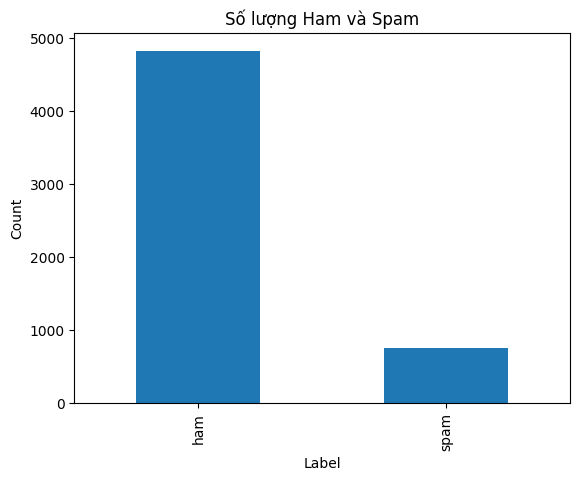

In [6]:

df["label"].value_counts().plot(kind="bar")

plt.title("Số lượng Ham và Spam")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()



# 7. Encode label

Máy học không hiểu chữ `ham` và `spam`, nên ta cần chuyển label thành số.

Ta quy ước:

| Label gốc | Label số |
|---|---|
| ham | 0 |
| spam | 1 |

Trong bài toán này:

- `0` nghĩa là không spam
- `1` nghĩa là spam


In [7]:

df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0



# 8. Tách biến đầu vào X và biến mục tiêu y

Trong bài toán này:

- `X`: nội dung tin nhắn/email
- `y`: nhãn spam hoặc không spam

```text
X = message text
y = spam label
```


In [8]:

X = df["message"]
y = df["label_num"]

print("Số lượng mẫu:", len(X))
print("Ví dụ message:", X.iloc[0])
print("Ví dụ label:", y.iloc[0])


Số lượng mẫu: 5572
Ví dụ message: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Ví dụ label: 0



# 9. Chia dữ liệu Train/Test

Ta chia dữ liệu thành:

- **Training set**: dùng để train model
- **Testing set**: dùng để kiểm tra model trên dữ liệu chưa từng thấy

Ở đây ta dùng:

```python
test_size = 0.2
```

Tức là:

- 80% dữ liệu để train
- 20% dữ liệu để test

Tham số `stratify=y` giúp giữ tỷ lệ spam/ham tương tự ở cả tập train và test.


In [9]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 4457
Test size: 1115



# 10. Biến text thành số bằng TF-IDF

Logistic Regression không thể học trực tiếp từ text.

Ví dụ model không hiểu câu:

```text
Congratulations! You won money
```

Vì vậy ta cần chuyển text thành vector số.

## TF-IDF là gì?

**TF-IDF** là kỹ thuật biến văn bản thành số dựa trên mức độ quan trọng của từ.

Ý tưởng đơn giản:

- Từ xuất hiện nhiều trong một tin nhắn → có thể quan trọng
- Nhưng nếu từ đó xuất hiện ở quá nhiều tin nhắn → giảm độ quan trọng
- Từ đặc trưng như `free`, `win`, `urgent`, `claim` thường quan trọng trong spam

Ở đây ta dùng:

```python
TfidfVectorizer(stop_words="english")
```

`stop_words="english"` giúp loại bỏ các từ tiếng Anh quá phổ biến như:

- the
- is
- and
- to


In [10]:

tfidf = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    max_df=0.95,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Shape của X_train_tfidf:", X_train_tfidf.shape)
print("Shape của X_test_tfidf:", X_test_tfidf.shape)


Shape của X_train_tfidf: (4457, 3401)
Shape của X_test_tfidf: (1115, 3401)



# 11. Train Logistic Regression

Logistic Regression dùng để dự đoán xác suất một mẫu thuộc class 1.

Trong bài này:

```text
class 1 = spam
class 0 = ham
```

Công thức sigmoid:

$$
P(y=1) = \frac{1}{1 + e^{-z}}
$$

Trong đó:

$$
z = w_1x_1 + w_2x_2 + ... + w_nx_n + b
$$

Ý nghĩa:

- Nếu xác suất gần 1 → model nghiêng về spam
- Nếu xác suất gần 0 → model nghiêng về ham
- Mặc định nếu xác suất >= 0.5 → dự đoán spam


In [11]:

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'



# 12. Dự đoán trên tập test

Sau khi train xong, ta dùng model để dự đoán nhãn cho dữ liệu test.


In [12]:

y_pred = model.predict(X_test_tfidf)

y_pred[:10]


array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0])


# 13. Đánh giá model bằng Accuracy

Accuracy cho biết tỷ lệ dự đoán đúng trên toàn bộ tập test.

Công thức:

$$
Accuracy = \frac{\text{Số dự đoán đúng}}{\text{Tổng số dự đoán}}
$$

Tuy nhiên, với bài toán spam detection, chỉ dùng accuracy là chưa đủ.

Vì nếu dataset có quá nhiều `ham`, model đoán toàn bộ là `ham` vẫn có thể đạt accuracy cao nhưng lại bắt spam kém.

Do đó ta cần xem thêm confusion matrix và classification report.


In [13]:

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.9730941704035875



# 14. Confusion Matrix

Confusion matrix giúp ta hiểu model sai ở đâu.

Với bài spam classification:

| Loại | Ý nghĩa |
|---|---|
| True Negative | Ham được dự đoán đúng là ham |
| False Positive | Ham bị dự đoán nhầm là spam |
| False Negative | Spam bị dự đoán nhầm là ham |
| True Positive | Spam được dự đoán đúng là spam |

Trong thực tế, **False Negative** khá nguy hiểm vì spam lọt qua bộ lọc.


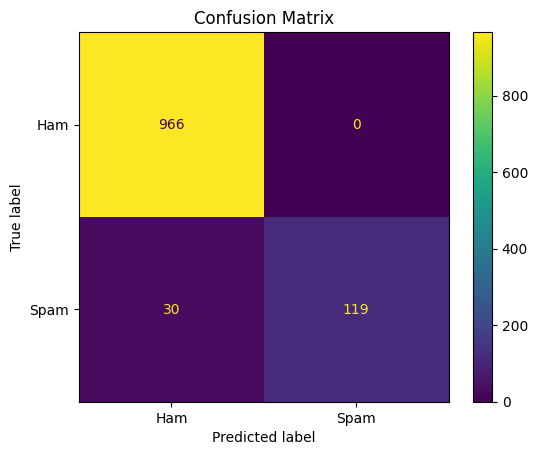

In [14]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()



# 15. Classification Report

Classification report gồm các chỉ số quan trọng:

## Precision

Trong các tin nhắn model dự đoán là spam, có bao nhiêu cái thật sự là spam?

$$
Precision = \frac{TP}{TP + FP}
$$

## Recall

Trong tất cả tin nhắn spam thật sự, model bắt được bao nhiêu cái?

$$
Recall = \frac{TP}{TP + FN}
$$

## F1-score

F1-score là trung bình hài hòa giữa Precision và Recall.

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

Với spam detection, Recall của class spam rất quan trọng vì ta muốn bắt được càng nhiều spam càng tốt.


In [15]:

print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))


              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.80      0.89       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115




# 16. Dự đoán xác suất spam

Ngoài việc dự đoán class 0 hoặc 1, Logistic Regression còn có thể trả về xác suất.

Ví dụ:

```text
P(spam) = 0.92
```

nghĩa là model cho rằng tin nhắn có 92% khả năng là spam.


In [16]:

y_proba = model.predict_proba(X_test_tfidf)

# Cột 0 là xác suất ham
# Cột 1 là xác suất spam
y_proba[:5]


array([[0.98503119, 0.01496881],
       [0.96033171, 0.03966829],
       [0.95328998, 0.04671002],
       [0.16403685, 0.83596315],
       [0.98130799, 0.01869201]])


# 17. Demo dự đoán tin nhắn mới

Bây giờ ta thử nhập một vài tin nhắn mới để model dự đoán.

Quy trình vẫn giống lúc test:

```text
new message
   ↓
TF-IDF transform
   ↓
model predict
```

Lưu ý quan trọng:

Ta dùng `tfidf.transform()`, không dùng `fit_transform()`.

Vì:

- `fit_transform()` chỉ dùng cho training data
- `transform()` dùng cho data mới


In [17]:

new_messages = [
    "Congratulations! You have won a free ticket. Claim now!",
    "Hi bro, are we still meeting for lunch tomorrow?",
    "URGENT! Your account has been selected for a cash prize.",
    "Can you send me the assignment file tonight?"
]

new_messages_tfidf = tfidf.transform(new_messages)

predictions = model.predict(new_messages_tfidf)
probabilities = model.predict_proba(new_messages_tfidf)

for msg, pred, proba in zip(new_messages, predictions, probabilities):
    label = "Spam" if pred == 1 else "Ham"
    spam_probability = proba[1]

    print("Message:", msg)
    print("Prediction:", label)
    print("Spam probability:", round(spam_probability, 4))
    print("-" * 80)


Message: Congratulations! You have won a free ticket. Claim now!
Prediction: Spam
Spam probability: 0.728
--------------------------------------------------------------------------------
Message: Hi bro, are we still meeting for lunch tomorrow?
Prediction: Ham
Spam probability: 0.0328
--------------------------------------------------------------------------------
Message: URGENT! Your account has been selected for a cash prize.
Prediction: Spam
Spam probability: 0.8207
--------------------------------------------------------------------------------
Message: Can you send me the assignment file tonight?
Prediction: Ham
Spam probability: 0.0776
--------------------------------------------------------------------------------



# 18. Xem các từ có ảnh hưởng mạnh đến spam

Logistic Regression học trọng số cho từng từ.

- Trọng số dương cao → từ đó làm tăng khả năng spam
- Trọng số âm thấp → từ đó làm tăng khả năng ham

Ta có thể xem các từ có trọng số cao nhất cho class spam.


In [18]:

feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "word": feature_names,
    "coefficient": coefficients
})

top_spam_words = coef_df.sort_values(by="coefficient", ascending=False).head(20)
top_ham_words = coef_df.sort_values(by="coefficient", ascending=True).head(20)

print("Top words indicating Spam:")
display(top_spam_words)

print("Top words indicating Ham:")
display(top_ham_words)


Top words indicating Spam:


,word,coefficient
3103,txt,4.719637
3117,uk,3.640717
780,claim,3.466010
2005,mobile,3.428855
3353,www,3.341321
2645,service,3.165670
2841,stop,3.095912
2500,reply,3.062475
1282,free,3.007755
111,150p,2.979206


Top words indicating Ham:


,word,coefficient
1812,ll,-1.714516
2165,ok,-1.705971
1408,gt,-1.636000
1865,lt,-1.619530
1503,home,-1.348571
816,come,-1.292145
1387,got,-1.272793
927,da,-1.270368
1835,lor,-1.177527
2777,sorry,-1.145879



# 19. Kết luận

Trong bài này, ta đã xây dựng thành công model phân loại spam bằng Logistic Regression.

## Những bước đã làm

1. Tải dataset thật từ Kaggle
2. Đọc và kiểm tra dữ liệu
3. Encode label `ham/spam` thành `0/1`
4. Chia dữ liệu thành train/test
5. Biến text thành vector số bằng TF-IDF
6. Train Logistic Regression
7. Đánh giá model bằng:
   - Accuracy
   - Confusion Matrix
   - Precision
   - Recall
   - F1-score
8. Dự đoán tin nhắn mới
9. Xem các từ ảnh hưởng mạnh đến spam/ham

---

## Ý nghĩa thực tế

Bài toán này là ví dụ cơ bản của:

```text
Supervised Learning
Binary Classification
Text Classification
Spam Detection
```

Đây là một bài rất tốt để luyện nền tảng Machine Learning trước khi học sâu hơn về NLP hoặc Deep Learning.



# 20. Bài tập tự luyện

## Bài 1

Thử thay đổi tham số của `TfidfVectorizer`, ví dụ:

```python
max_df=0.9
min_df=3
ngram_range=(1, 2)
```

Sau đó so sánh accuracy và F1-score.

---

## Bài 2

Thử dự đoán thêm 5 tin nhắn mới do bạn tự viết.

---

## Bài 3

So sánh Logistic Regression với Naive Bayes:

```python
from sklearn.naive_bayes import MultinomialNB
```

Model nào có Recall tốt hơn cho class spam?

---

## Bài 4

Giải thích vì sao trong spam detection, Recall của class spam thường quan trọng.
